In [1]:
import pandas as pd

# - Data Extraction

- how many of the employees are active or not active how many were terminated volunterely and involunterely

In [2]:
df=pd.read_csv('Attrition_dataset.csv')
df.head()

,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
0,1318,12/31/2006 0:00,01-03-1954,8/28/1989,01-01-1900,52,17,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2006,ACTIVE,HEADOFFICE
1,1318,12/31/2007 0:00,01-03-1954,8/28/1989,01-01-1900,53,18,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2007,ACTIVE,HEADOFFICE
2,1318,12/31/2008 0:00,01-03-1954,8/28/1989,01-01-1900,54,19,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2008,ACTIVE,HEADOFFICE
3,1318,12/31/2009 0:00,01-03-1954,8/28/1989,01-01-1900,55,20,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2009,ACTIVE,HEADOFFICE
4,1318,12/31/2010 0:00,01-03-1954,8/28/1989,01-01-1900,56,21,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2010,ACTIVE,HEADOFFICE


- df.shape( ) is used to find the no, of records and columns present in the data set.
- So here we have 49653 records and 18 columns.

In [3]:
df.shape

(49653, 18)

- df.info( ) will give us the summary of the DataFrame

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49653 entries, 0 to 49652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   EmployeeID           49653 non-null  int64 
 1   recorddate_key       49653 non-null  object
 2   birthdate_key        49653 non-null  object
 3   orighiredate_key     49653 non-null  object
 4   terminationdate_key  49653 non-null  object
 5   age                  49653 non-null  int64 
 6   length_of_service    49653 non-null  int64 
 7   city_name            49653 non-null  object
 8   department_name      49653 non-null  object
 9   job_title            49653 non-null  object
 10  store_name           49653 non-null  int64 
 11  gender_short         49653 non-null  object
 12  gender_full          49653 non-null  object
 13  termreason_desc      49653 non-null  object
 14  termtype_desc        49653 non-null  object
 15  STATUS_YEAR          49653 non-null  int64 
 16  STAT

# - Data Cleaning

- Checking for null values present in the columns or series
- checking for the duplicate records

In [5]:
df.duplicated(subset='EmployeeID').any()

True

- As we dont any null values in the df so we are checking for the duplicate values.
- Used duplicated( ).any( ) to check if there are any duplicate records present or not.
- We are checking here based on the EmployeeID

In [6]:
df=df.drop_duplicates(subset='EmployeeID', keep='last')

- using drop_duplicates(subset='EmployeeID',keep='last') we are droping the duplicate records based on employee ID and by default it keeps the first record but we want the last record so we use keep='last'.

In [7]:
df.shape

(6284, 18)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6284 entries, 9 to 49652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   EmployeeID           6284 non-null   int64 
 1   recorddate_key       6284 non-null   object
 2   birthdate_key        6284 non-null   object
 3   orighiredate_key     6284 non-null   object
 4   terminationdate_key  6284 non-null   object
 5   age                  6284 non-null   int64 
 6   length_of_service    6284 non-null   int64 
 7   city_name            6284 non-null   object
 8   department_name      6284 non-null   object
 9   job_title            6284 non-null   object
 10  store_name           6284 non-null   int64 
 11  gender_short         6284 non-null   object
 12  gender_full          6284 non-null   object
 13  termreason_desc      6284 non-null   object
 14  termtype_desc        6284 non-null   object
 15  STATUS_YEAR          6284 non-null   int64 
 16  STATUS    

In [9]:
col=['recorddate_key', 'birthdate_key', 'orighiredate_key', 'terminationdate_key']
for i in col:
    df[i]=pd.to_datetime(df[i], format='mixed')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6284 entries, 9 to 49652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   EmployeeID           6284 non-null   int64         
 1   recorddate_key       6284 non-null   datetime64[ns]
 2   birthdate_key        6284 non-null   datetime64[ns]
 3   orighiredate_key     6284 non-null   datetime64[ns]
 4   terminationdate_key  6284 non-null   datetime64[ns]
 5   age                  6284 non-null   int64         
 6   length_of_service    6284 non-null   int64         
 7   city_name            6284 non-null   object        
 8   department_name      6284 non-null   object        
 9   job_title            6284 non-null   object        
 10  store_name           6284 non-null   int64         
 11  gender_short         6284 non-null   object        
 12  gender_full          6284 non-null   object        
 13  termreason_desc      6284 non-null   

In [11]:
df=df.reset_index(drop=True)

In [12]:
df=df.drop(columns=['store_name','gender_short'])

In [13]:
df

,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,2015,ACTIVE,HEADOFFICE
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,2015,ACTIVE,HEADOFFICE
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,2015,ACTIVE,HEADOFFICE
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,2015,ACTIVE,HEADOFFICE
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,2015,ACTIVE,HEADOFFICE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,2015,TERMINATED,STORES
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,TERMINATED,STORES
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,2015,TERMINATED,STORES
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,TERMINATED,STORES


In [14]:
df.columns

Index(['EmployeeID', 'recorddate_key', 'birthdate_key', 'orighiredate_key',
       'terminationdate_key', 'age', 'length_of_service', 'city_name',
       'department_name', 'job_title', 'gender_full', 'termreason_desc',
       'termtype_desc', 'STATUS_YEAR', 'STATUS', 'BUSINESS_UNIT'],
      dtype='object')

In [15]:
col_lst=['ID', 'Record_date', 'DOB', 'Hire_date', 'Termi_date', 'Age', 'Experience', 'City',
         'Dname', 'Job', 'Gender', 'Termi_reason', 'Termi_type', 'Year', 'Status', 'Business_unit']
df.columns=col_lst

In [16]:
df

,ID,Record_date,DOB,Hire_date,Termi_date,Age,Experience,City,Dname,Job,Gender,Termi_reason,Termi_type,Year,Status,Business_unit
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,2015,ACTIVE,HEADOFFICE
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,2015,ACTIVE,HEADOFFICE
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,2015,ACTIVE,HEADOFFICE
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,2015,ACTIVE,HEADOFFICE
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,2015,ACTIVE,HEADOFFICE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,2015,TERMINATED,STORES
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,TERMINATED,STORES
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,2015,TERMINATED,STORES
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,TERMINATED,STORES


In [17]:
df['Status']=df['Status'].str.title()
df['Business_unit']=df['Business_unit'].str.title()

In [18]:
df

,ID,Record_date,DOB,Hire_date,Termi_date,Age,Experience,City,Dname,Job,Gender,Termi_reason,Termi_type,Year,Status,Business_unit
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,2015,Active,Headoffice
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,2015,Active,Headoffice
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,2015,Active,Headoffice
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,2015,Active,Headoffice
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,2015,Active,Headoffice
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,2015,Terminated,Stores
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,Terminated,Stores
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,2015,Terminated,Stores
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,Terminated,Stores


In [19]:
df[['Age', 'Experience']].agg(['min','max'])

,Age,Experience
min,19,0
max,65,26


In [20]:
df['Age_category']=pd.cut(df['Age'], bins=[18,25,59,65], labels=['Teen', 'Adult', 'Senior'])

In [21]:
df

,ID,Record_date,DOB,Hire_date,Termi_date,Age,Experience,City,Dname,Job,Gender,Termi_reason,Termi_type,Year,Status,Business_unit,Age_category
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Senior
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,2015,Active,Headoffice,Senior
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,2015,Terminated,Stores,Teen
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,Terminated,Stores,Teen
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,2015,Terminated,Stores,Teen
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,Terminated,Stores,Teen


- Cut function can only used for continous numerical values 

In [22]:
df['Exp_category']=pd.cut(df['Experience'], bins=[-1,1,5,26], labels=['Fresher', 'Senior', 'Experts'])

In [23]:
df['Dname'].unique()

array(['Executive', 'Store Management', 'Meats', 'Recruitment',
       'Customer Service', 'Produce', 'Bakery', 'Dairy',
       'Processed Foods', 'Training', 'Labor Relations', 'HR Technology',
       'Employee Records', 'Compensation', 'Legal',
       'Accounts Receiveable', 'Information Technology',
       'Accounts Payable', 'Audit', 'Accounting', 'Investment'],
      dtype=object)

In [24]:
df['Job'].unique()

array(['CEO', 'VP Stores', 'Legal Counsel', 'VP Human Resources',
       'VP Finance', 'Exec Assistant, VP Stores',
       'Exec Assistant, Legal Counsel', 'CHief Information Officer',
       'Store Manager', 'Meats Manager',
       'Exec Assistant, Human Resources', 'Exec Assistant, Finance',
       'Director, Recruitment', 'Meat Cutter', 'Customer Service Manager',
       'Produce Manager', 'Bakery Manager', 'Dairy Person',
       'Processed Foods Manager', 'Produce Clerk', 'Baker',
       'Shelf Stocker', 'Cashier', 'Director, Training',
       'Director, Labor Relations', 'Director, HR Technology',
       'Director, Employee Records', 'Director, Compensation',
       'Corporate Lawyer', 'Director, Accounts Receivable',
       'Systems Analyst', 'Director, Accounts Payable', 'Director, Audit',
       'Director, Accounting', 'Director, Investments', 'Recruiter',
       'Trainer', 'Labor Relations Analyst', 'Dairy Manager',
       'HRIS Analyst', 'Benefits Admin', 'Compensation Analys

In [25]:
def job_clean(row):
    j=row['Job']
    d=row['Dname']
    if j!='Auditor' and j!='Dairy Person':
        if d in j:
            return j.replace(d,'').strip().strip(',').strip(', s')
        else:
            return j.removeprefix('Exec Assistant').strip(', ')
    return j

In [26]:
df['Job']=df.apply(job_clean, axis=1)

In [27]:
df['Job'].unique()

array(['CEO', 'VP Stores', 'Legal Counsel', 'VP Human Resources',
       'VP Finance', 'CHief Information Officer', 'Store Manager',
       'Manager', 'Human Resources', 'Finance', 'Director', 'Meat Cutter',
       'Dairy Person', 'Clerk', 'Baker', 'Shelf Stocker', 'Cashier',
       'Corporate Lawyer', 'Director, Accounts Receivable',
       'Systems Analyst', 'Recruiter', 'Trainer', 'Analyst',
       'HRIS Analyst', 'Benefits Admin', 'Auditor'], dtype=object)

In [28]:
df['Job']=df['Job'].replace({'CHief Information Officer': 'Cheif information officer'})

In [29]:
df['Job'].unique()

array(['CEO', 'VP Stores', 'Legal Counsel', 'VP Human Resources',
       'VP Finance', 'Cheif information officer', 'Store Manager',
       'Manager', 'Human Resources', 'Finance', 'Director', 'Meat Cutter',
       'Dairy Person', 'Clerk', 'Baker', 'Shelf Stocker', 'Cashier',
       'Corporate Lawyer', 'Director, Accounts Receivable',
       'Systems Analyst', 'Recruiter', 'Trainer', 'Analyst',
       'HRIS Analyst', 'Benefits Admin', 'Auditor'], dtype=object)

In [30]:
df

,ID,Record_date,DOB,Hire_date,Termi_date,Age,Experience,City,Dname,Job,Gender,Termi_reason,Termi_type,Year,Status,Business_unit,Age_category,Exp_category
0,1318,2015-12-31,1954-01-03,1989-08-28,1900-01-01,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Senior,Experts
1,1319,2015-12-31,1957-01-03,1989-08-28,1900-01-01,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts
2,1320,2015-12-31,1955-01-02,1989-08-28,1900-01-01,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,2015,Active,Headoffice,Senior,Experts
3,1321,2015-12-31,1959-01-02,1989-08-28,1900-01-01,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts
4,1322,2015-12-31,1958-01-09,1989-08-31,1900-01-01,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,2015,Terminated,Stores,Teen,Senior
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,Terminated,Stores,Teen,Fresher
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,2015,Terminated,Stores,Teen,Senior
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,Terminated,Stores,Teen,Fresher


In [31]:
df.loc[df['Status']=='Active', 'Record_date'].unique()

<DatetimeArray>
['2015-12-31 00:00:00']
Length: 1, dtype: datetime64[ns]

In [32]:
df.loc[df['Status']=='Active', 'Termi_date'].unique()

<DatetimeArray>
['1900-01-01 00:00:00']
Length: 1, dtype: datetime64[ns]

In [33]:
df.loc[df['Status']=='Active', 'Termi_date']='2015-12-31'

In [34]:
df.loc[df['Status']=='Active', 'Termi_date'].unique()

<DatetimeArray>
['2015-12-31 00:00:00']
Length: 1, dtype: datetime64[ns]

In [35]:
h_df=df['Hire_date'].dt.year.value_counts().sort_values().reset_index()

In [36]:
# col=['Year','Hirings']
h_df.columns=['Year','Hirings']

In [37]:
h_df

,Year,Hirings
0,1989,86
1,1991,200
2,2001,212
3,2004,214
4,1990,214
5,2013,218
6,2003,218
7,2007,237
8,2002,238
9,2006,239


In [38]:
t_df=df.loc[df['Status']=='Terminated', 'Termi_date'].dt.year.value_counts().sort_values().reset_index()

In [39]:
t_df.columns=['Year', 'Termination']

In [40]:
t_df

,Year,Termination
0,2013,105
1,2011,110
2,2010,123
3,2012,130
4,2006,134
5,2009,142
6,2007,162
7,2015,162
8,2008,164
9,2014,253


In [41]:
df1=pd.merge(left=h_df, right=t_df, on='Year', how='outer').fillna(0).astype(int)

In [42]:
df1

,Year,Hirings,Termination
0,1989,86,0
1,1990,214,0
2,1991,200,0
3,1992,248,0
4,1993,298,0
5,1994,298,0
6,1995,312,0
7,1996,273,0
8,1997,312,0
9,1998,341,0


In [43]:
df1['Retention1']=df1['Hirings']-df1['Termination']

In [44]:
df1

,Year,Hirings,Termination,Retention1
0,1989,86,0,86
1,1990,214,0,214
2,1991,200,0,200
3,1992,248,0,248
4,1993,298,0,298
5,1994,298,0,298
6,1995,312,0,312
7,1996,273,0,273
8,1997,312,0,312
9,1998,341,0,341


- Applying cumulative sum on the retention1 column
- Add each and every value till the end of the records

In [45]:
df1['Retention']=df1['Retention1'].cumsum()

In [46]:
df1=df1.drop(columns='Retention1')

In [47]:
df1

,Year,Hirings,Termination,Retention
0,1989,86,0,86
1,1990,214,0,300
2,1991,200,0,500
3,1992,248,0,748
4,1993,298,0,1046
5,1994,298,0,1344
6,1995,312,0,1656
7,1996,273,0,1929
8,1997,312,0,2241
9,1998,341,0,2582


In [48]:
df

,ID,Record_date,DOB,Hire_date,Termi_date,Age,Experience,City,Dname,Job,Gender,Termi_reason,Termi_type,Year,Status,Business_unit,Age_category,Exp_category
0,1318,2015-12-31,1954-01-03,1989-08-28,2015-12-31,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Senior,Experts
1,1319,2015-12-31,1957-01-03,1989-08-28,2015-12-31,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts
2,1320,2015-12-31,1955-01-02,1989-08-28,2015-12-31,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,2015,Active,Headoffice,Senior,Experts
3,1321,2015-12-31,1959-01-02,1989-08-28,2015-12-31,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts
4,1322,2015-12-31,1958-01-09,1989-08-31,2015-12-31,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,8258,2015-12-01,1994-05-28,2013-08-19,2015-12-30,21,2,Valemount,Dairy,Dairy Person,Male,Layoff,Involuntary,2015,Terminated,Stores,Teen,Senior
6280,8264,2013-08-01,1994-06-13,2013-08-27,2013-08-30,19,0,Vancouver,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,Terminated,Stores,Teen,Fresher
6281,8279,2015-12-01,1994-07-18,2013-09-15,2015-12-30,21,2,White Rock,Customer Service,Cashier,Female,Layoff,Involuntary,2015,Terminated,Stores,Teen,Senior
6282,8296,2013-12-01,1994-09-02,2013-10-09,2013-12-31,19,0,Kelowna,Customer Service,Cashier,Female,Resignaton,Voluntary,2013,Terminated,Stores,Teen,Fresher


In [49]:
df.loc[df['Status']=='Active'].shape

(4799, 18)

# Analyzing and Visualizing the cleaned data.


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df.head()

,ID,Record_date,DOB,Hire_date,Termi_date,Age,Experience,City,Dname,Job,Gender,Termi_reason,Termi_type,Year,Status,Business_unit,Age_category,Exp_category
0,1318,2015-12-31,1954-01-03,1989-08-28,2015-12-31,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Senior,Experts
1,1319,2015-12-31,1957-01-03,1989-08-28,2015-12-31,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts
2,1320,2015-12-31,1955-01-02,1989-08-28,2015-12-31,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,2015,Active,Headoffice,Senior,Experts
3,1321,2015-12-31,1959-01-02,1989-08-28,2015-12-31,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts
4,1322,2015-12-31,1958-01-09,1989-08-31,2015-12-31,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts


In [52]:
df.shape

(6284, 18)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6284 entries, 0 to 6283
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID             6284 non-null   int64         
 1   Record_date    6284 non-null   datetime64[ns]
 2   DOB            6284 non-null   datetime64[ns]
 3   Hire_date      6284 non-null   datetime64[ns]
 4   Termi_date     6284 non-null   datetime64[ns]
 5   Age            6284 non-null   int64         
 6   Experience     6284 non-null   int64         
 7   City           6284 non-null   object        
 8   Dname          6284 non-null   object        
 9   Job            6284 non-null   object        
 10  Gender         6284 non-null   object        
 11  Termi_reason   6284 non-null   object        
 12  Termi_type     6284 non-null   object        
 13  Year           6284 non-null   int64         
 14  Status         6284 non-null   object        
 15  Business_unit  6284 n

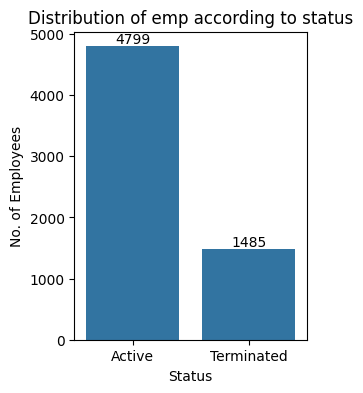

In [54]:
plt.figure(figsize=(3,4))
c=sns.countplot(data=df,x='Status')
plt.bar_label(c.containers[0])
plt.ylabel('No. of Employees')
plt.title('Distribution of emp according to status')
plt.show()

***Observation***
- More employees are active compared to the terminated employees.

In [55]:
c=df['Gender'].value_counts()
c.values
c.index

Index(['Female', 'Male'], dtype='object', name='Gender')

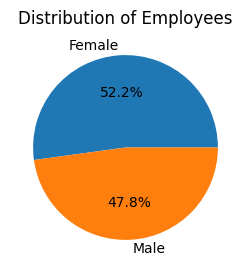

In [56]:
plt.figure(figsize=(3,3))
plt.pie(x=c,labels=c.index, autopct='%.1f%%')
plt.title('Distribution of Employees')
# plt.legend()
plt.show()

- The workforce is balanced with slight majority of female, than the male

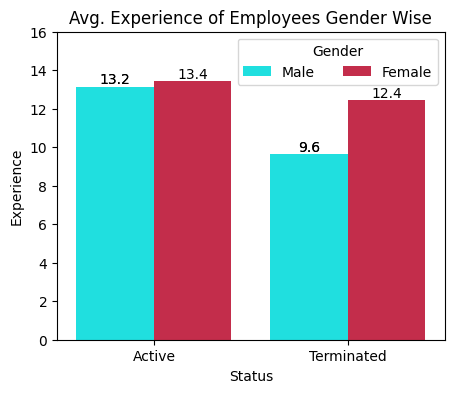

In [57]:
plt.figure(figsize=(5,4))
c=sns.barplot(data=df, x='Status', y='Experience',errorbar=None,hue='Gender', palette=('cyan','crimson'))
for i in c.containers:
    c.bar_label(i, fmt='%.1f')
plt.bar_label(c.containers[0],fmt='%.1f')
plt.yticks(range(0,17,2))
plt.title('Avg. Experience of Employees Gender Wise')
plt.legend(ncol=2, title='Gender')
plt.show()


***Observation***

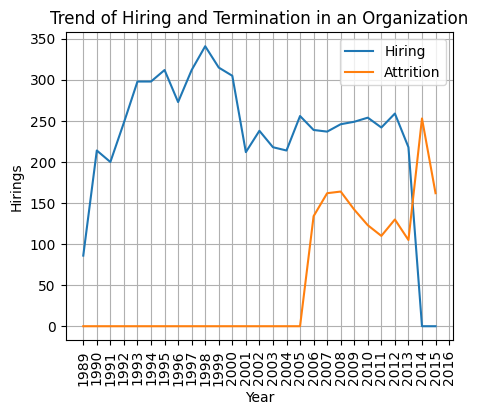

In [58]:
plt.figure(figsize=(5,4))
sns.lineplot(data=df1,x='Year',y='Hirings', label='Hiring')
sns.lineplot(data=df1,x='Year',y='Termination', label='Attrition')
plt.xticks(range(1989,2017), rotation=90)
plt.title('Trend of Hiring and Termination in an Organization')
plt.grid()
plt.show()

***Observation***
- More no. of employees were hired in the year 1998
- More no. of employees were terminated in the year 2014

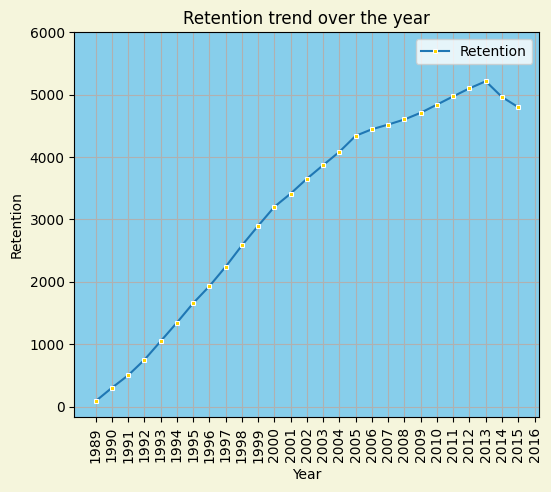

In [59]:
plt.figure(figsize=(6,5),facecolor='beige')
e=sns.lineplot(data=df1, x='Year', y='Retention',label='Retention', marker='s', markersize=3,markerfacecolor='gold')
e.set_facecolor('skyblue')
plt.xticks(range(1989,2017), rotation=90)
plt.yticks(range(0,7000,1000))
plt.title('Retention trend over the year')
plt.grid()


***Observation***
- There was more retention in the year 2013

In [60]:
t=df.loc[df['Status']=='Terminated']
tt=t['Termi_type'].value_counts()

In [61]:
tr=t['Termi_reason'].value_counts()

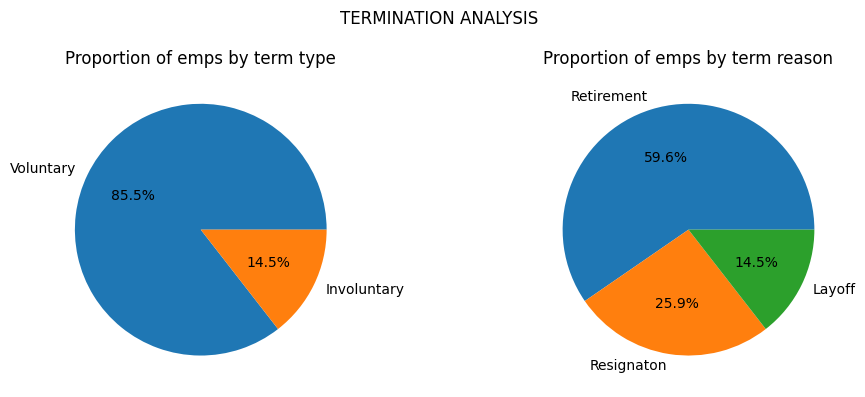

In [62]:
fig,axes=plt.subplots(nrows=1,ncols=2, figsize=(10,4))
plt.suptitle('TERMINATION ANALYSIS')

axes[0].pie(x=tt.values, labels=tt.index, autopct='%.1f%%', labeldistance=1.1)
axes[0].set_title('Proportion of emps by term type')

axes[1].pie(x=tr.values, labels=tr.index, autopct='%.1f%%', labeldistance=1.1)
axes[1].set_title('Proportion of emps by term reason')

plt.tight_layout()
plt.show()


***Observation***
- Most of the employees exit voluntaryly (85.5%) due to Retirement or Resignation while other exit voluntaryly due to layoff.

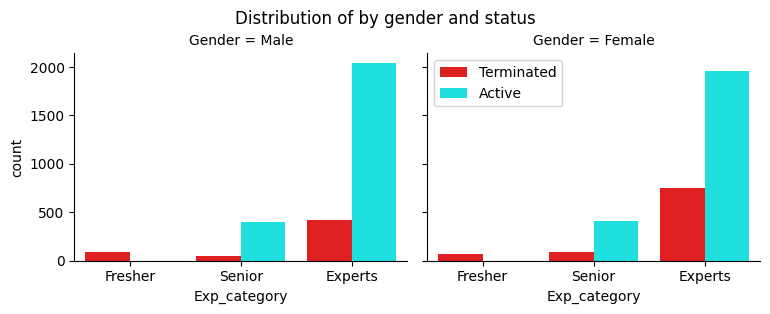

In [63]:
fg=sns.FacetGrid(df, col='Gender', aspect=1.3)
fg.map_dataframe(sns.countplot,x='Exp_category', hue='Status', palette=['red','cyan'], hue_order=['Terminated','Active'])
plt.suptitle('Distribution of by gender and status', y=1.03)
plt.legend(loc='best')
plt.show()

In [64]:
df.head()

,ID,Record_date,DOB,Hire_date,Termi_date,Age,Experience,City,Dname,Job,Gender,Termi_reason,Termi_type,Year,Status,Business_unit,Age_category,Exp_category
0,1318,2015-12-31,1954-01-03,1989-08-28,2015-12-31,61,26,Vancouver,Executive,CEO,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Senior,Experts
1,1319,2015-12-31,1957-01-03,1989-08-28,2015-12-31,58,26,Vancouver,Executive,VP Stores,Female,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts
2,1320,2015-12-31,1955-01-02,1989-08-28,2015-12-31,60,26,Vancouver,Executive,Legal Counsel,Female,Not Applicable,Not Applicable,2015,Active,Headoffice,Senior,Experts
3,1321,2015-12-31,1959-01-02,1989-08-28,2015-12-31,56,26,Vancouver,Executive,VP Human Resources,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts
4,1322,2015-12-31,1958-01-09,1989-08-31,2015-12-31,57,26,Vancouver,Executive,VP Finance,Male,Not Applicable,Not Applicable,2015,Active,Headoffice,Adult,Experts


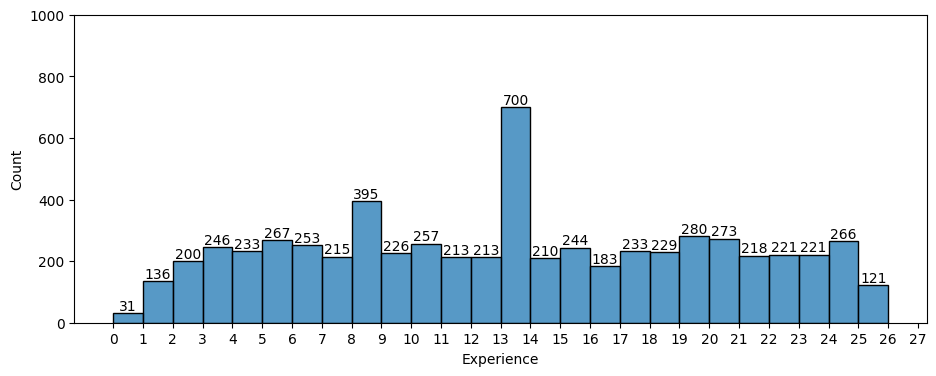

In [65]:
plt.figure(figsize=(11,4))
c=sns.histplot(df,x='Experience', bins=26)
plt.bar_label(c.containers[0])
plt.xticks(range(0,28))
plt.yticks(range(0,1001,200))
plt.show()

***Observation***
- 700 employees have experience of 13-14 years
- But its not the exact count 

## - Kernal Density estimator
- continuous plot
- used for continuous range of values
- only used for numerical data
- it gives the distribution of data
- it gives the result in form of density 
- here we can predict exact values using the curves

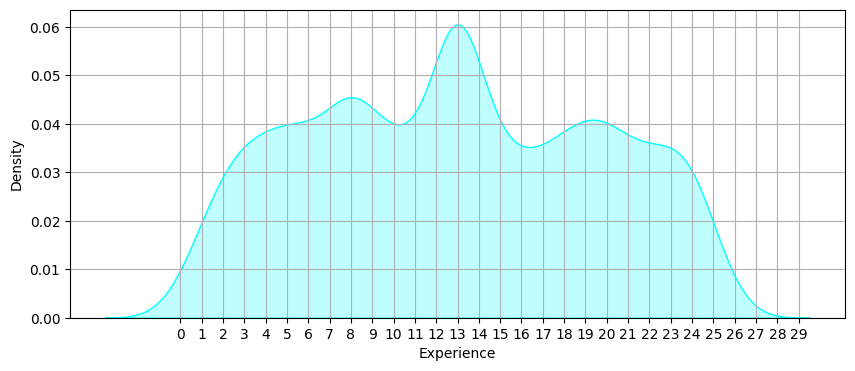

In [66]:
plt.figure(figsize=(10,4))
sns.kdeplot(df,x='Experience', color='cyan', fill=True)
plt.xticks(range(0,30))
plt.grid()

***Observation***
- Based on the kernel density estimator graph we can conclude that there are more employees with 13 years experience.

In [67]:
import numpy as np

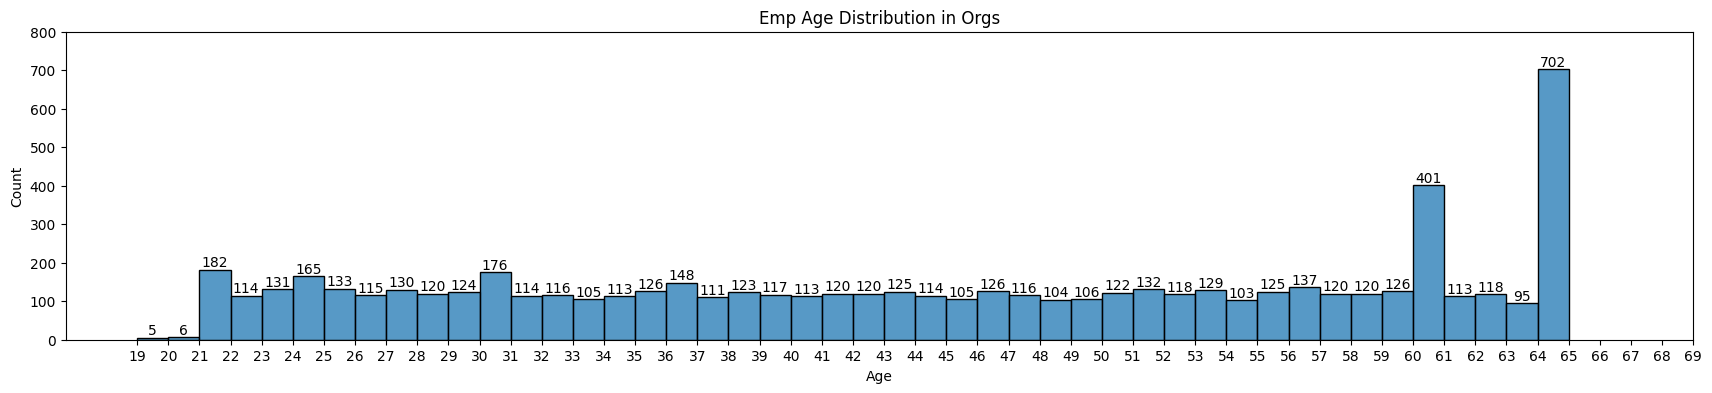

In [68]:
plt.figure(figsize=(21,4))
c=sns.histplot(df,x='Age',bins=46)
plt.bar_label(c.containers[0])
plt.title('Emp Age Distribution in Orgs')
plt.yticks(range(0,801,100))
plt.xticks(range(19,70))
plt.show()

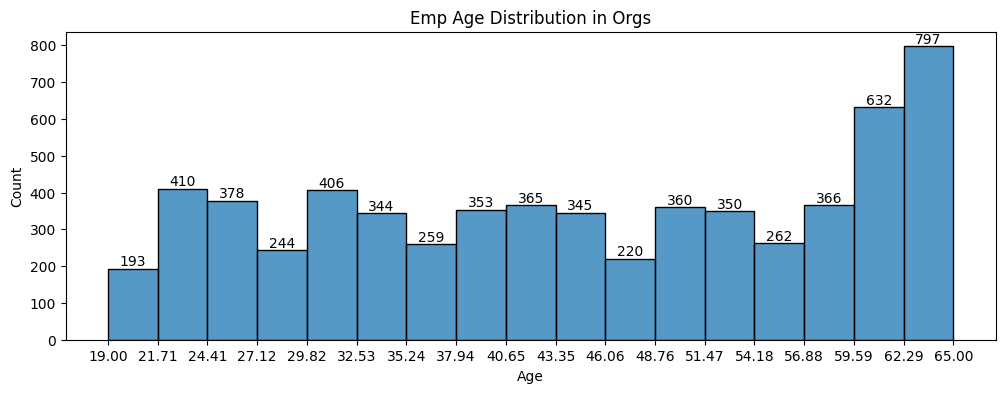

In [69]:
plt.figure(figsize=(12,4))
c=sns.histplot(df,x='Age')
plt.bar_label(c.containers[0])
plt.title('Emp Age Distribution in Orgs')
plt.xticks(np.linspace(19,65,18))
plt.show()

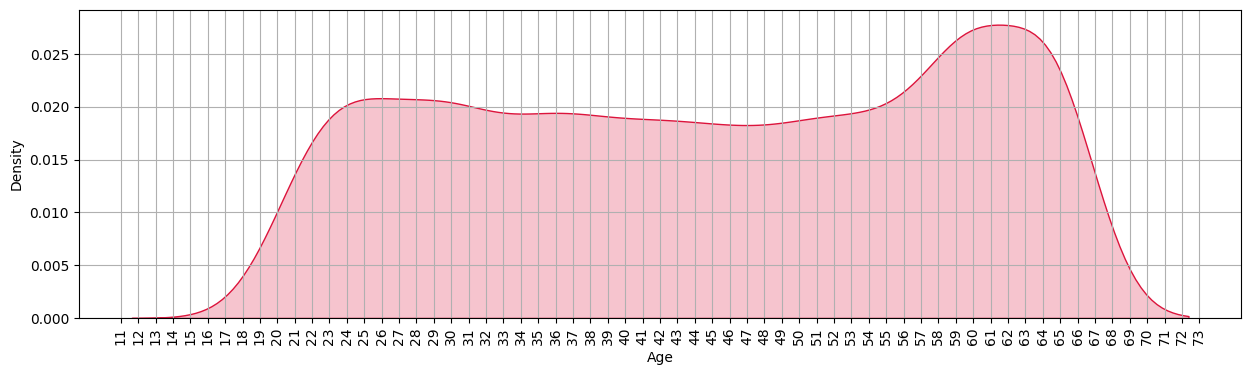

In [70]:
plt.figure(figsize=(15,4))
sns.kdeplot(df,x='Age',color='crimson', fill=True)
plt.xticks(range(11,74), rotation=90)
plt.grid()

***Observation***
- Most of the employees age is between 61 - 62.

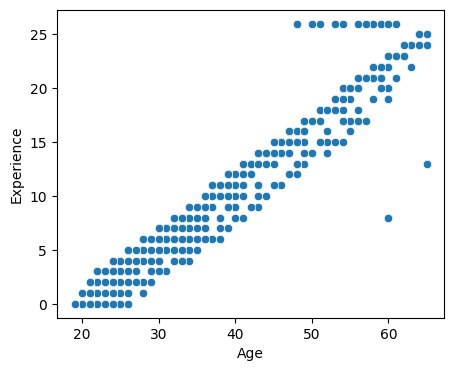

In [71]:
plt.figure(figsize=(5,4))
sns.scatterplot(df,x='Age',y='Experience')
plt.show()

***Observation***
- Age and Experience columns are highly correlated as the scatter plot is producing a stright line pattern , strongly positive relation.

In [72]:
df.corr(numeric_only=True)

,ID,Age,Experience,Year
ID,1.000000,-0.946295,-0.928050,0.225236
Age,-0.946295,1.000000,0.849308,-0.338389
Experience,-0.928050,0.849308,1.000000,0.137111
Year,0.225236,-0.338389,0.137111,1.000000


### jointplot( )
- It will give the combination of the plot based on the given type of data.

<Figure size 300x400 with 0 Axes>

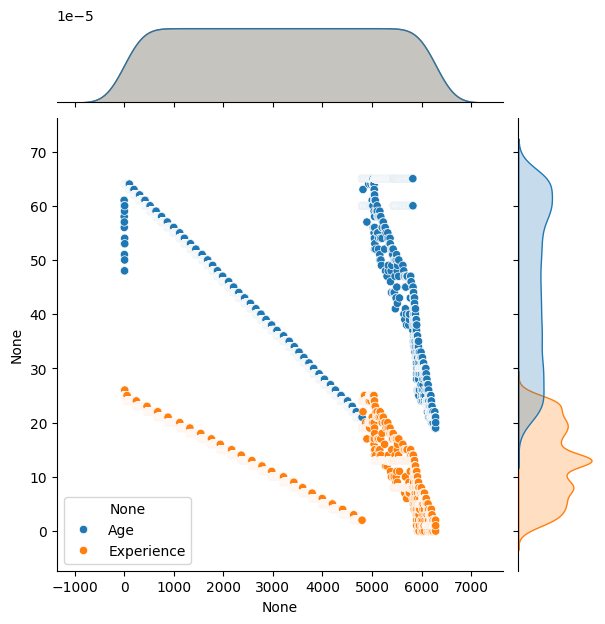

In [73]:
# sns.jointplot(df,x='Age',y='Experience')
plt.figure(figsize=(3,4),)
sns.jointplot(df[['Age','Experience']])
plt.show()

<Axes: >

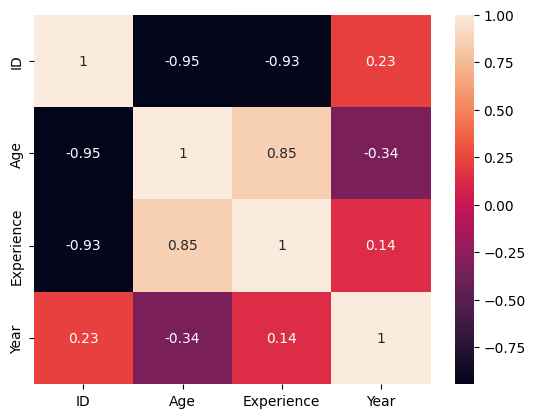

In [74]:
a=df.corr(numeric_only=True)
sns.heatmap(a, annot=True)

###  pairplot( )
- It is used to plot the graph for the whole DataFrame
- Gives only for the numerical columns

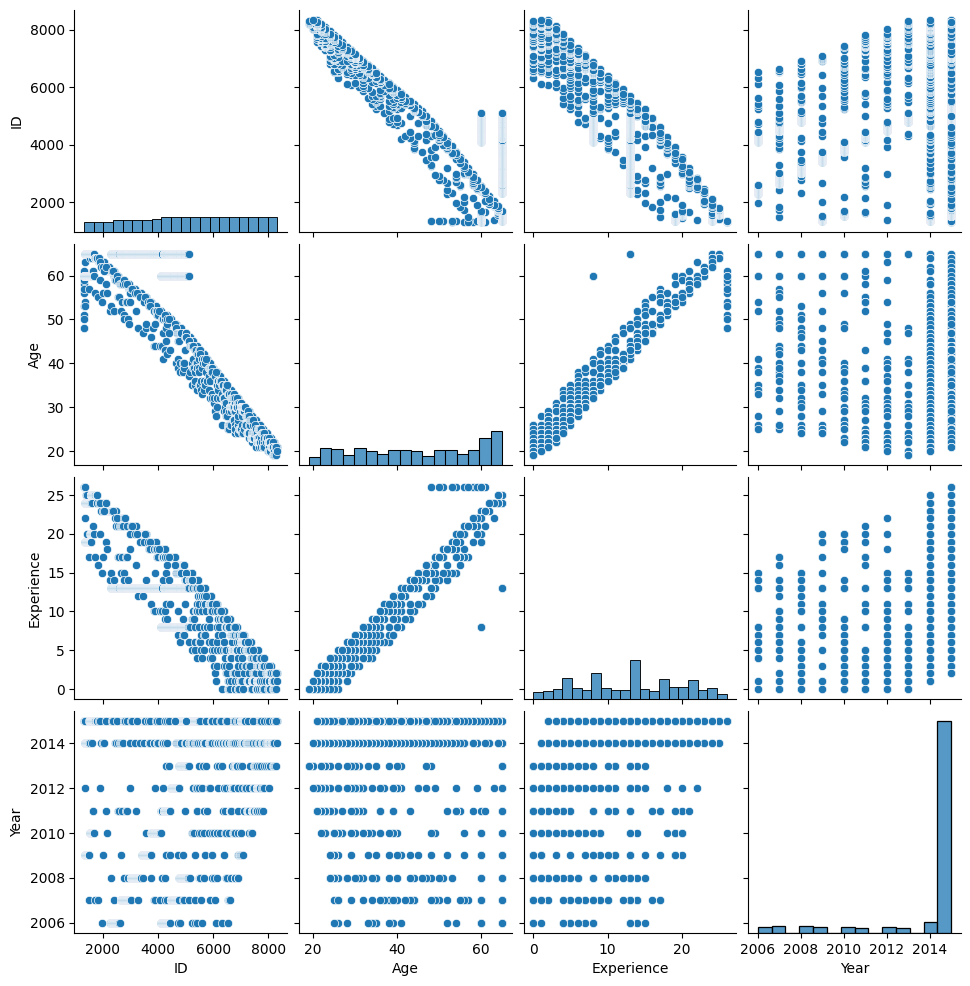

In [75]:
sns.pairplot(df)
plt.show()

### Boxplot( )
- Is a Univarient as well as Bivarient plot
- Boxplot is used to identify the outliers and the distribution
- Outliers are the data points which is far away or data points far away from the majority of data 
- Distribution is spread of data
- Used to fill the null values

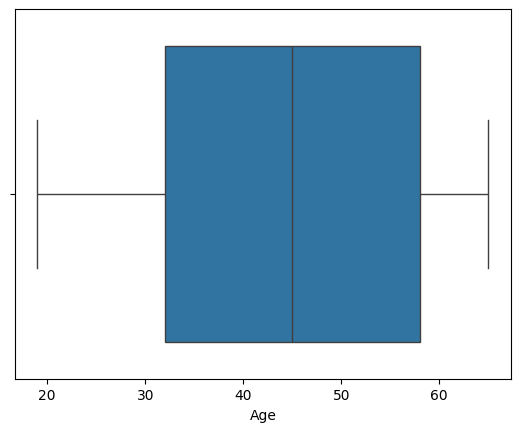

In [85]:
sns.boxplot(df,x='Age')
plt.show()

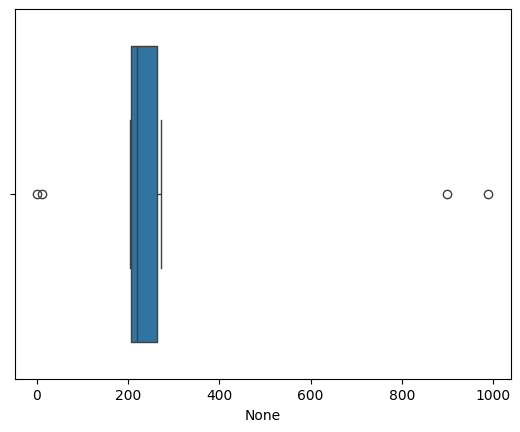

In [80]:
l=[220,225,272,215,1,10,990,900,203,255,210]
s=pd.Series(l)
sns.boxplot(x=s)
plt.show()

### Conclusion

* Performed **Exploratory Data Analysis (EDA)** on the Employee Attrition dataset by cleaning the data, removing duplicate employee records, and preparing it for analysis.
* Analyzed employee characteristics such as **employment status, gender, experience, hiring trends, and attrition patterns** using various visualizations.
* Identified key insights, including a higher number of active employees than terminated employees, workforce distribution by gender, and yearly hiring and termination trends.
* Explored employee retention and organizational trends to better understand factors associated with workforce changes.
* Overall, this analysis provides meaningful business insights into employee attrition and serves as a strong foundation for **HR analytics, workforce planning, and predictive attrition modeling**.
